In [43]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from matplotlib import cm
from collections import deque

$\LARGE Edge\ Detection$

$Finite\ Difference\ Filters$

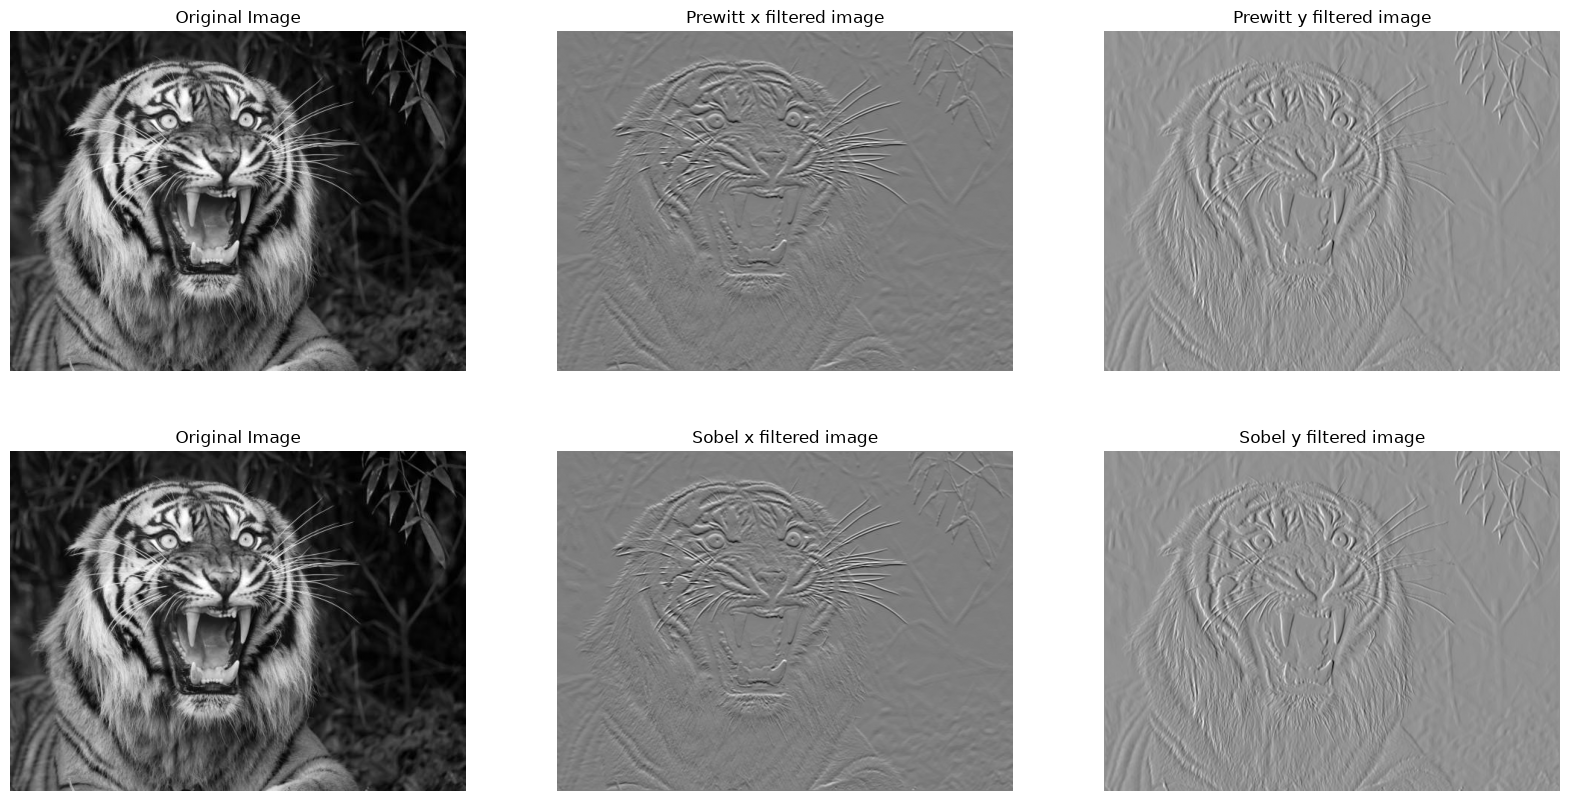

In [2]:
im = cv.imread('images/Tiger.jpg', cv.IMREAD_GRAYSCALE)
assert im is not None

#Prewitt filters
prewitt_x = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])
prewitt_y = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])

#Sobel filters
sobel_x = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
sobel_y = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])

prewitt_filtered_x = cv.filter2D(im, cv.CV_32F, prewitt_x)
prewitt_filtered_y = cv.filter2D(im, cv.CV_32F, prewitt_y)

sobel_filtered_x = cv.filter2D(im, cv.CV_32F, sobel_x)
sobel_filtered_y = cv.filter2D(im, cv.CV_32F, sobel_y)

#Normalizing
prewitt_filtered_x = cv.normalize(prewitt_filtered_x, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)
prewitt_filtered_y = cv.normalize(prewitt_filtered_y, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)
sobel_filtered_x = cv.normalize(sobel_filtered_x, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)
sobel_filtered_y = cv.normalize(sobel_filtered_y, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)

fig, ax = plt.subplots(2, 3, figsize = (20, 10))

ax[0, 0].imshow(im, cmap='gray')
ax[0, 0].set_title('Original Image')

ax[1, 0].imshow(im, cmap='gray')
ax[1, 0].set_title('Original Image')

ax[0, 1].imshow(prewitt_filtered_x, cmap='gray')
ax[0, 1].set_title('Prewitt x filtered image')

ax[0, 2].imshow(prewitt_filtered_y, cmap='gray')
ax[0, 2].set_title('Prewitt y filtered image')

ax[1, 1].imshow(sobel_filtered_x, cmap='gray')
ax[1, 1].set_title('Sobel x filtered image')

ax[1, 2].imshow(sobel_filtered_y, cmap='gray')
ax[1, 2].set_title('Sobel y filtered image')

for a in ax.ravel():
    a.axis('off')

plt.show()


$Derivatives\ of\ Gaussian\ Filters$

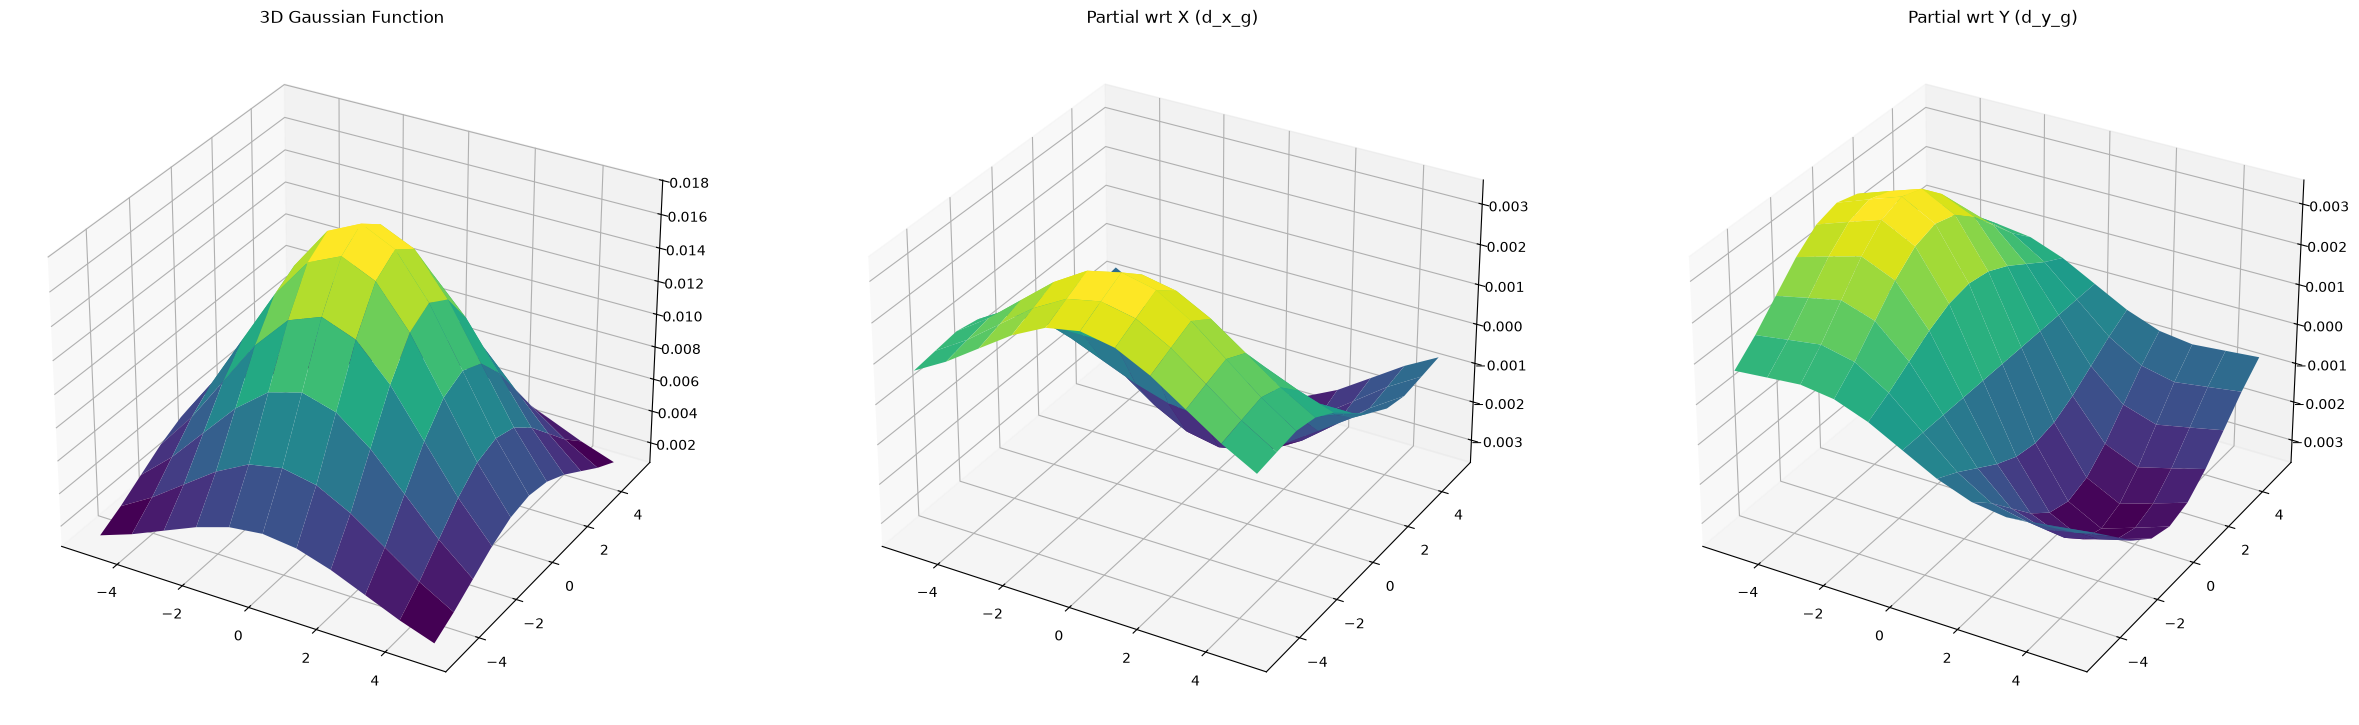

In [3]:
#Gaussian function
sigma = 3.0
x = np.arange(-5, 5.1, 1)
y = np.arange(-5, 5.1, 1)
x, y = np.meshgrid(x, y)

g_xy = (1/(2*np.pi*sigma**2)) * np.exp(-(x**2 + y**2)/(2*sigma**2))

d_x_g, d_y_g = np.gradient(g_xy)

fig, ax = plt.subplots(1, 3, figsize=(30, 10), subplot_kw={'projection': '3d'})

ax[0].plot_surface(x, y, g_xy, cmap='viridis')
ax[0].set_title('3D Gaussian Function')

ax[1].plot_surface(x, y, d_x_g, cmap='viridis')
ax[1].set_title('Partial wrt X (d_x_g)')

ax[2].plot_surface(x, y, d_y_g, cmap='viridis')
ax[2].set_title('Partial wrt Y (d_y_g)')

plt.show()



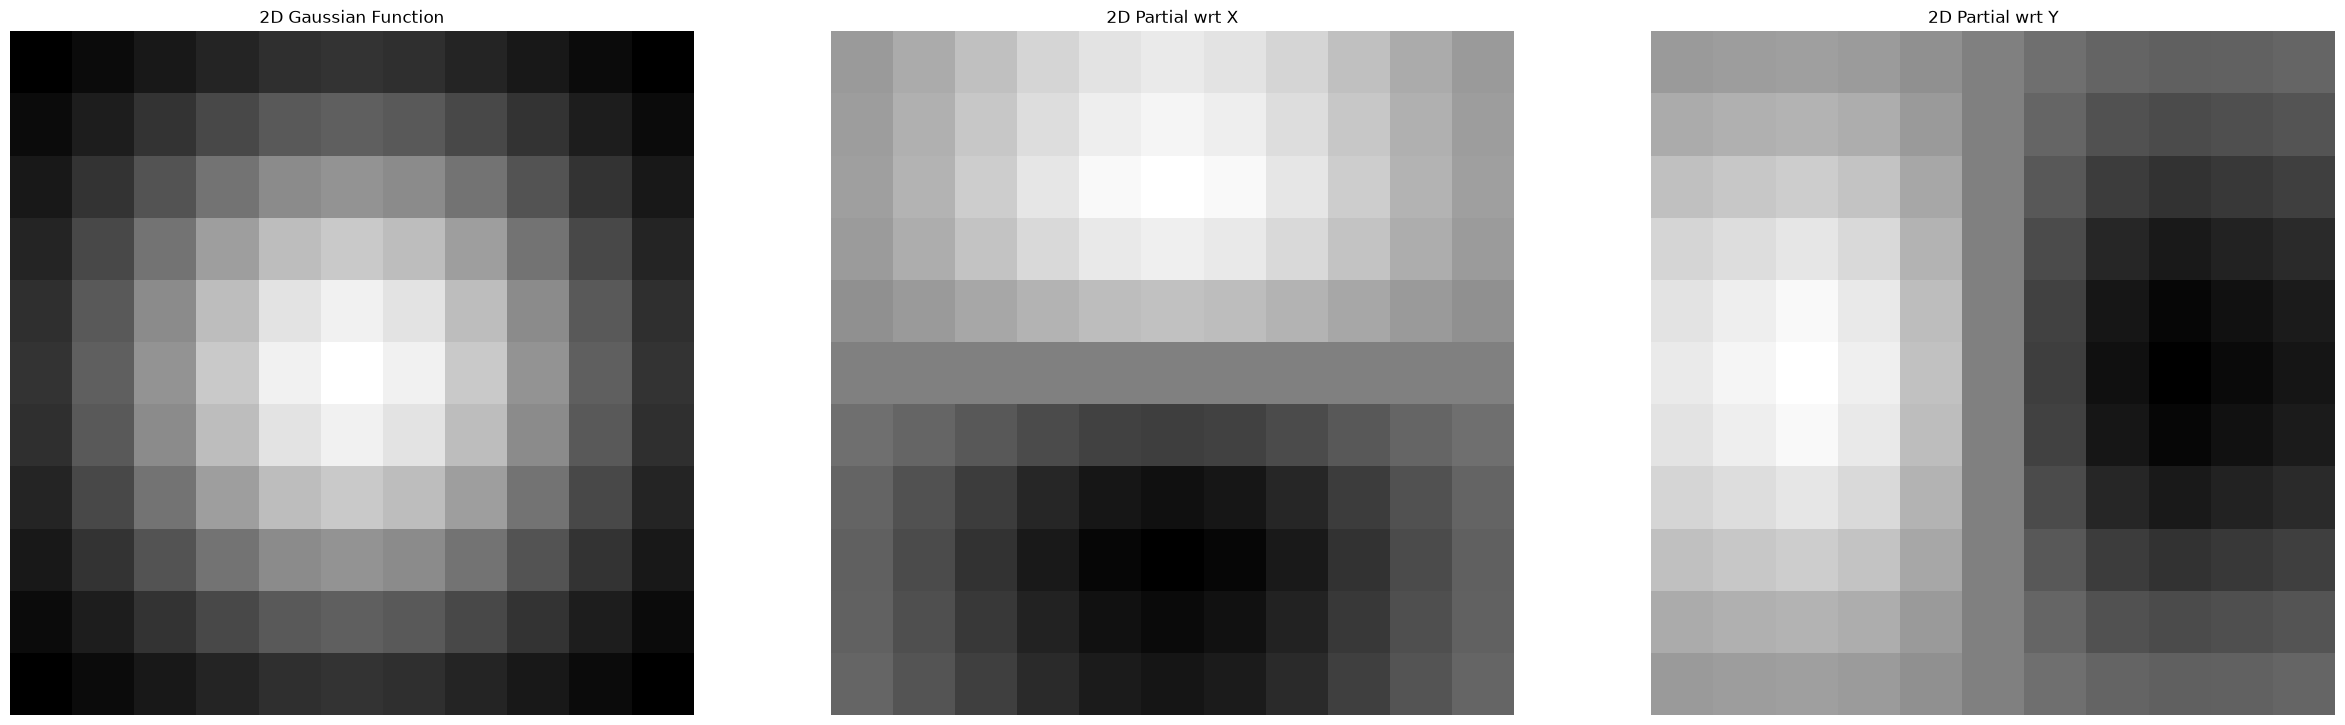

In [4]:
fig, ax = plt.subplots(1, 3, figsize = (30, 10))

ax[0].imshow(g_xy, cmap='gray')
ax[0].set_title('2D Gaussian Function')

ax[1].imshow(d_x_g, cmap='gray')
ax[1].set_title('2D Partial wrt X')

ax[2].imshow(d_y_g, cmap='gray')
ax[2].set_title('2D Partial wrt Y')

for a in ax:
    a.axis('off')

plt.show()



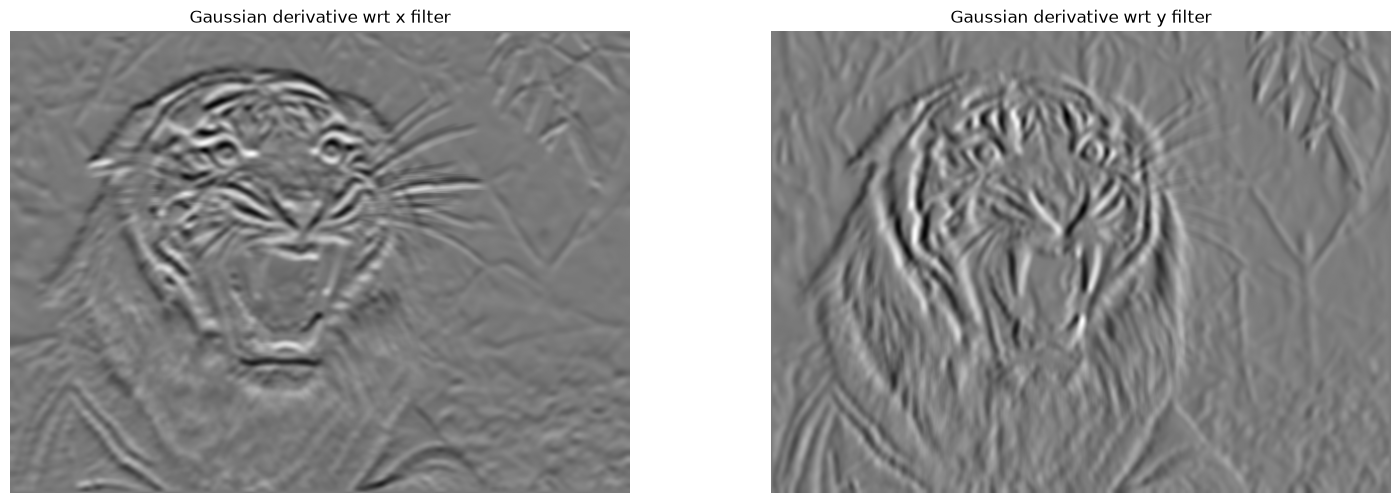

In [5]:
#Applying filters
im_gauss_x = cv.filter2D(im, cv.CV_32F, d_x_g)
im_gauss_y = cv.filter2D(im, cv.CV_32F, d_y_g)

#Normalizing
im_gauss_x = cv.normalize(im_gauss_x, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U) 
im_gauss_y = cv.normalize(im_gauss_y, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)

fig, ax = plt.subplots(1, 2, figsize = (18,6))
ax[0].imshow(im_gauss_x, cmap='gray')
ax[0].set_title('Gaussian derivative wrt x filter')

ax[1].imshow(im_gauss_y, cmap='gray')
ax[1].set_title('Gaussian derivative wrt y filter')

for a in ax:
    a.axis('off')

plt.show()





$Canny\ Edge\ Detector$

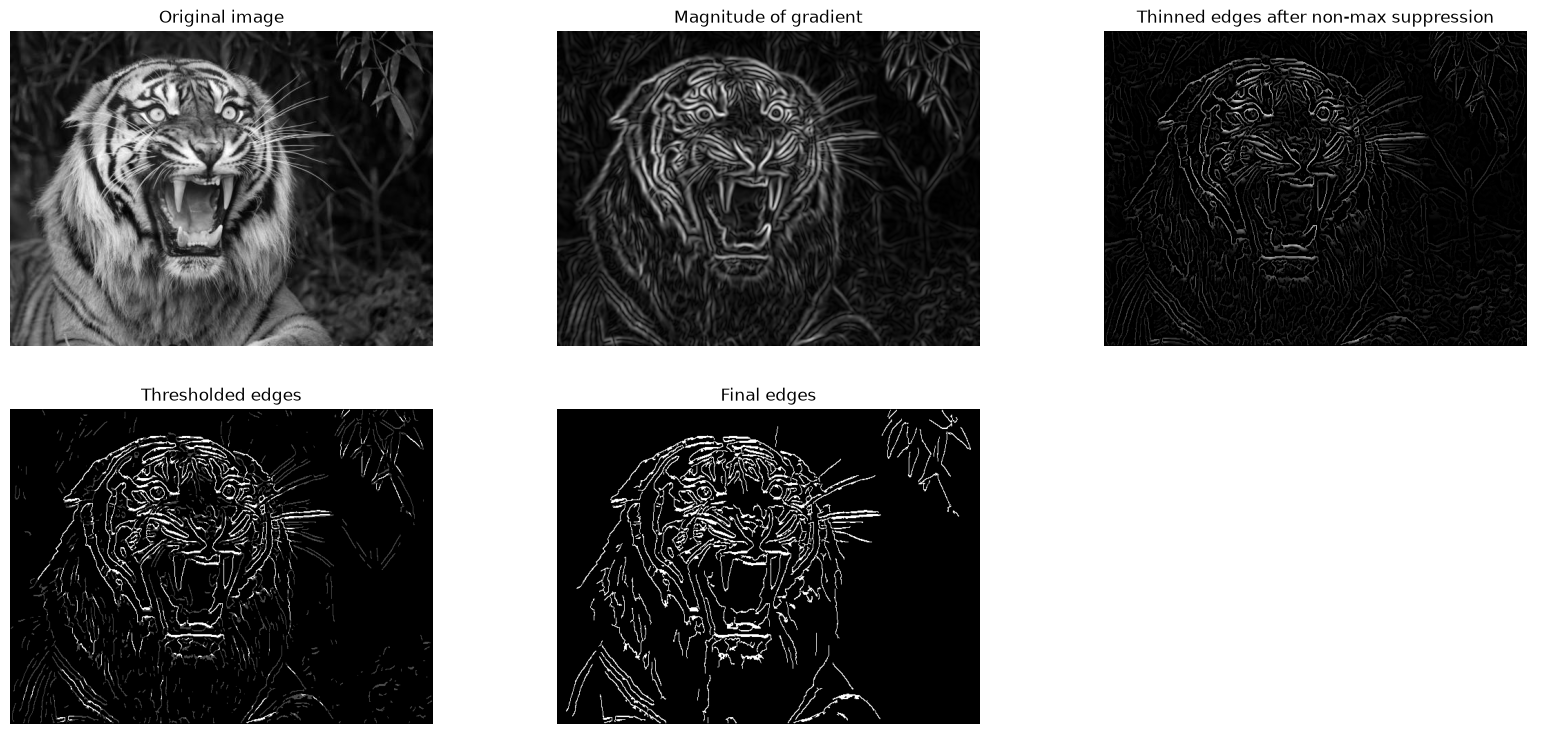

In [122]:
#Loaging the image
im_new = cv.imread('images/Tiger.jpg', cv.IMREAD_GRAYSCALE)
assert im_new is not None

sigma = 2
x = np.arange(-5, 5.1, 1) 
y = np.arange(-5, 5.1, 1)

x, y = np.meshgrid(x, y) 

# Gaussian function and derivatives
g_xy = (1/(2*np.pi*sigma**2)) * np.exp(-(x**2 + y**2)/(2*sigma**2))
d_x_g, d_y_g = np.gradient(g_xy)

#Filtering the image with derivative of Gaussian
im_new_d_gaus_x = cv.filter2D(im_new, cv.CV_64F, d_x_g)
im_new_d_gaus_y = cv.filter2D(im_new, cv.CV_64F, d_y_g)

#Computing the magnitude of the gradient
im_mag = np.sqrt(im_new_d_gaus_x**2 + im_new_d_gaus_y**2)

#Computing the orientation of the gradient
im_orient = np.arctan2(im_new_d_gaus_y, im_new_d_gaus_x) * (180 / np.pi)

#Normalizing
im_mag_norm = cv.normalize(im_mag, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)

#Non maximum suppression function
def NMS(magnitude_img, angle_img):

    #Creating a blank image to contain the values
    thinned_edges = np.zeros_like(magnitude_img)

    #Number of rows and columns of the image
    rows, columns = np.shape(magnitude_img)

    #Iterating through the image
    #The reason for the range is we are not going thorugh the most outer pixels because they lack one neighbour because of that we start iteration from the immediate inner pixels
    for i in range(1, rows-1): 
        for j in range(1, columns-1):

            magnitude = magnitude_img[i, j]
            angle = angle_img[i, j]

            #Since we consider the pixels along the edge the direction and the opposite direction does not matter so we convert the angles to 0 to 180
            if angle < 0:
                angle += 180

            #And here since we are in the discrete world we quantize the angle values like this

            #0 degrees
            if (0 <= angle < 22.5) or (157.5 <= angle <= 180):

                #Declaring the neighbours
                q = magnitude_img[i + 1, j]
                r = magnitude_img[i + 1, j]

            #45 degrees
            elif 22.5 <= angle < 67.5:

                #Declaring the neighbours
                q = magnitude_img[i - 1, j - 1]
                r = magnitude_img[i + 1, j + 1]

            #90 dgrees
            elif 67.5 <= angle < 112.5:

                #Declaring the neighbours
                q = magnitude_img[i , j + 1]
                r = magnitude_img[i , j - 1]

            #135 degrees
            elif 112.5 <= angle < 157.5:

                #Declaring the neighbours
                q = magnitude_img[i + 1, j - 1]
                r = magnitude_img[i - 1, j + 1]


            #Non Maximum Supression
            if (magnitude >= q) and (magnitude >= r) :
                thinned_edges[i, j] = magnitude
            else:
                thinned_edges[i, j] = 0

    return thinned_edges

#Calling the Non Maximum supression
im_nms = NMS(im_mag_norm, im_orient)

#Double Thresholding
#Thresholds
high_threshold = 80
low_threshold = 40

#Edge intensity declaration
strong = 255
weak = 75
non_edge = 0

#Initial blank image
im_thresh = np.zeros_like(im_nms)

#Choosing the points 
high = im_nms >= high_threshold
low = (im_nms >= low_threshold) & (im_nms < high_threshold)

#Assigning values
im_thresh[high] = strong
im_thresh[low] = weak

#Linking function
def linking(thresholded_img, strong = 255, weak = 75):

    #Rows and columns
    rows, columns = np.shape(thresholded_img)

    #Creating blank image for the final edges
    edges = np.zeros_like(thresholded_img)

    #Creating a queue to store strong and connected pixels
    queue = deque()

    #Finding all strong pixels locations
    strong_pixels = np.argwhere(thresholded_img == strong)

    #Adding those strong pixels to the final image and the queue
    for i, j in strong_pixels:
        edges[i, j] = strong
        queue.append((i, j))

    #Defining the 8 neighbours of a single pixel
    neighbours = [
        (-1, -1), (-1, 0), (-1, 1),
        ( 0, -1),          ( 0, 1),
        ( 1, -1), ( 1, 0), ( 1, 1) 
    ]

    #Iterating until the queue is empty
    while queue:

        #Popping the leftmost element (FIFO)
        i, j = queue.popleft()

        #Going through the neighbours
        for di, dj in neighbours:
            ni = di + i
            nj = dj + j

            #Checking the image boundaries
            if (0 <= ni < rows) and (0 <= nj < columns) :

                #If neighbouring pixel is weak then it is connected
                if (thresholded_img[ni, nj] == weak) & (edges[ni, nj] == 0):

                    #So keep it
                    edges[ni, nj] = strong

                    #Add to the queue
                    queue.append((ni, nj))

    return edges

#Calling the linking function
im_edgs = linking(im_thresh, strong, weak)

fig, ax = plt.subplots(2, 3, figsize = (20, 9))
ax[0, 0].imshow(im_new, cmap = 'grey', vmin = 0, vmax = 255)
ax[0, 0].set_title("Original image")

ax[0, 1].imshow(im_mag_norm, cmap = 'grey', vmin = 0, vmax = 255)
ax[0, 1].set_title("Magnitude of gradient")

ax[0, 2].imshow(im_nms, cmap = 'grey', vmin = 0, vmax = 255)
ax[0, 2].set_title("Thinned edges after non-max suppression")

ax[1, 0].imshow(im_thresh, cmap = 'grey', vmin = 0, vmax = 255)
ax[1, 0].set_title("Thresholded edges")

ax[1, 1].imshow(im_edgs, cmap = 'grey', vmin = 0, vmax = 255)
ax[1, 1].set_title("Final edges")

for a in ax.ravel():
    a.axis('off')

plt.show()


$\LARGE Corner\ Detection$